In [ ]:
import sys
from pathlib import Path

# Add src folder to Python path
project_root = Path.cwd().parent
src_path = project_root / 'src' / 'eeg_synthetic'

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f'✓ Path setup complete: {src_path}')
import os
from data_loader import BCIAUTLoader, plot_normalized_arrays
from classifiers import EEGNetModel, TrainModel
import torch
import pandas as pd
from scipy import signal
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, roc_curve, accuracy_score
from torch.utils.data import TensorDataset
from scipy import linalg


Caricamento Soggetti: [3], Sessioni: [3], Modalità: ['Train']
-> Totale caricato: (1600, 8, 128) - Classi: (array([0, 1]), array([1400,  200]))
Caricamento Soggetti: [3], Sessioni: [3], Modalità: ['Test']
-> Totale caricato: (2800, 8, 128) - Classi: (array([0, 1]), array([2450,  350]))
--- Generazione Grafici NumPy ---


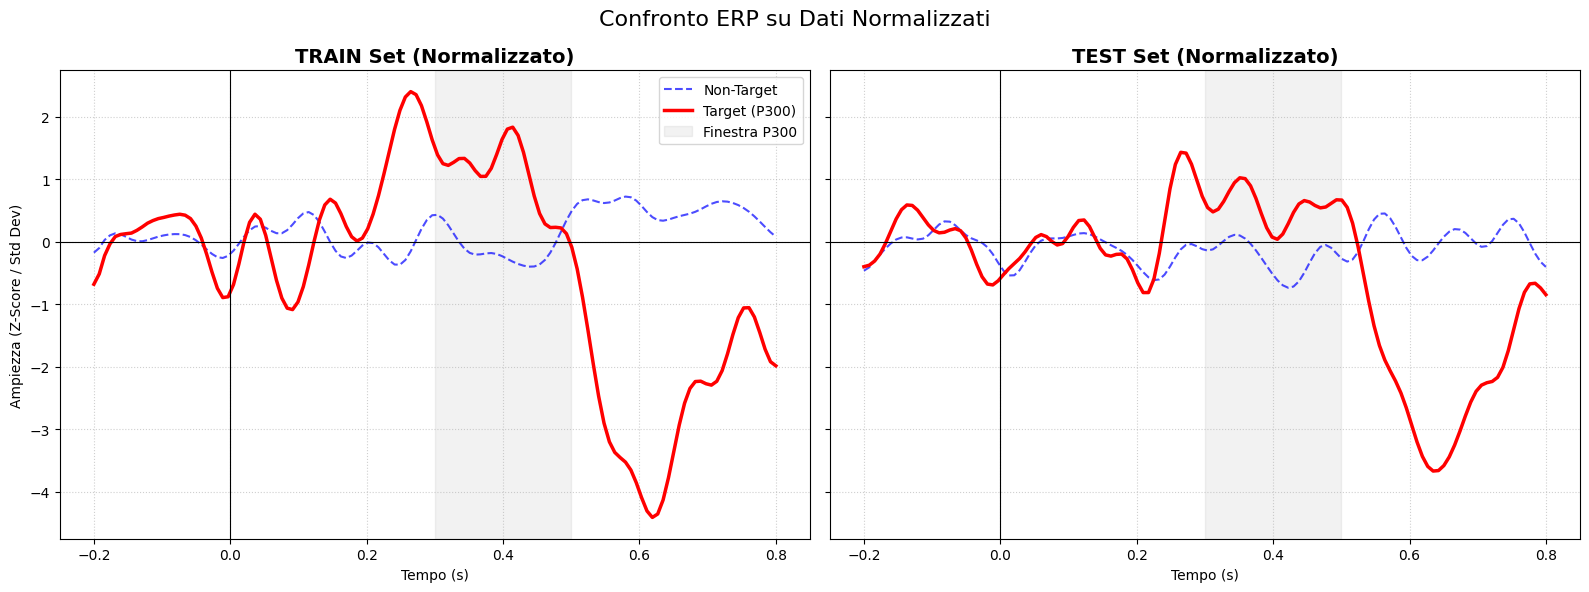

In [2]:
project_root = os.getcwd()
dataset_path = os.path.join(project_root, 'data') 
loader = BCIAUTLoader(dataset_path)
X_train_sess, y_train_sess, subjects_train_ids, session_train_ids = loader.get_data(subjects=[3], sessions=[3], modes=['Train'])
X_test_sess, y_test_sess, subjects_test_ids, session_test_ids   = loader.get_data(subjects=[3], sessions=[3], modes=['Test'])
plot_normalized_arrays(X_train_sess, y_train_sess, X_test_sess, y_test_sess)

In [3]:
def load_balanced_synthetic_limited(path_c0, path_c1, max_trials=1200):
    """
    Carica esplicitamente i primi 'max_trials' per classe 0 e classe 1.
    """
    rows_to_read = max_trials * 8

    def get_data_from_csv(path):
        if not os.path.exists(path):
            print(f"ERRORE: File non trovato {path}")
            return None, None
        df = pd.read_csv(path, nrows=rows_to_read)
        time_cols = [col for col in df.columns if col.startswith('Time')]
        X = df[time_cols].values
        y = df['Condition'].values
        return X, y
    print(f"Caricamento primi {max_trials} trial Classe 0...")
    X0_rows, y0_rows = get_data_from_csv(path_c0)
    
    print(f"Caricamento primi {max_trials} trial Classe 1...")
    X1_rows, y1_rows = get_data_from_csv(path_c1)
    X0_trial = torch.tensor(X0_rows).view(-1, 8, 128)
    y0_trial = torch.tensor(y0_rows[::8]) 
    
    X1_trial = torch.tensor(X1_rows).view(-1, 8, 128)
    y1_trial = torch.tensor(y1_rows[::8])

    return X0_trial, y0_trial, X1_trial, y1_trial
file_c0 = 'generated_samples/gen_data_c0_s3_sess3.csv'
file_c1 = 'generated_samples/gen_data_c1_s3_sess3.csv'
X0_syn, y0_syn, X1_syn, y1_syn = load_balanced_synthetic_limited(file_c0, file_c1, max_trials=8600)
X_syn_final = torch.cat([X0_syn, X1_syn], dim=0)
y_syn_final = torch.cat([y0_syn, y1_syn], dim=0)
print(f"Forma finale SINTETICI: X={X_syn_final.shape}, y={y_syn_final.shape}")

Caricamento primi 8600 trial Classe 0...
Caricamento primi 8600 trial Classe 1...
Forma finale SINTETICI: X=torch.Size([3800, 8, 128]), y=torch.Size([3800])


In [4]:
def mne_style_iir_filter(data, fs=128):
    low_cutoff = 0.1
    high_cutoff = 15.0
    order = 4
    # Progettazione filtro
    b, a = signal.butter(order, [low_cutoff, high_cutoff], btype='bandpass', fs=fs)
    # Applicazione a fase zero
    return signal.filtfilt(b, a, data, axis=-1)

def apply_final_alignment(x_tensor):
    """
    Applica Filtro e Baseline in modo identico a ogni trial del tensore.
    Input: torch.Tensor [Trials, Channels, Time]
    """
    # 1. Converti in numpy per il filtraggio
    x_np = x_tensor.detach().cpu().numpy()
    
    # 2. Applica il Filtro IIR (0.1-15Hz)
    # Questo sovrascrive il filtraggio precedente dei reali con la firma di Scipy
    x_filtered = mne_style_iir_filter(x_np, fs=128)
    
    # 3. Applica la Baseline Correction (Indici 0-26 per -0.2s a 0s)
    # Lo facciamo DOPO il filtro per correggere eventuali shift introdotti dal filtro stesso
    baseline_period = x_filtered[:, :, :26]
    baseline_mean = np.mean(baseline_period, axis=-1, keepdims=True)
    x_aligned = x_filtered - baseline_mean
    
    # 4. Riconverti in Tensore
    return torch.from_numpy(x_aligned.copy()).float()

In [5]:
X_syn_ready = apply_final_alignment(X_syn_final)
X_syn_filtered = torch.from_numpy(X_syn_ready.detach().cpu().numpy().copy()).float()
mu_syn = X_syn_filtered.mean(dim=(1, 2), keepdim=True)
std_syn = X_syn_filtered.std(dim=(1, 2), keepdim=True)
X_syn_filtered = (X_syn_filtered - mu_syn) / (std_syn)
X_grouped_perm = X_syn_filtered.permute(0, 2, 1) 
syn_win = X_grouped_perm[y_syn_final == 0.0]
syn_loss = X_grouped_perm[y_syn_final == 1.0]
X_train_tensor = torch.tensor(X_train_sess).float()
y_train_tensor = torch.tensor(y_train_sess).float()
X_test_sess_tensor = torch.tensor(X_test_sess).float()
y_test_sess_tensor = torch.tensor(y_test_sess).float()
X_train_tensor = apply_final_alignment(X_train_tensor)
X_test_sess_tensor  = apply_final_alignment(X_test_sess_tensor)
mu_ref = X_train_tensor.mean(dim=(1, 2), keepdim=True)
std_ref = X_train_tensor.std(dim=(1, 2), keepdim=True)
X_train_real_z = (X_train_tensor - mu_ref) / (std_ref)
mu_ref_test = X_test_sess_tensor.mean(dim=(1, 2), keepdim=True)
std_ref_test = X_test_sess_tensor.std(dim=(1, 2), keepdim=True)
X_test_real_z = (X_test_sess_tensor - mu_ref_test) / (std_ref_test)
X_train_real_ready = X_train_real_z.permute(0, 2, 1)
X_test_real_ready  = X_test_real_z.permute(0, 2, 1)
print(f"Reali pronti: Train {X_train_real_ready.shape}, Test {X_test_real_ready.shape}")
real_train_0 = X_train_real_ready[y_train_tensor == 0]
real_test_0  = X_test_real_ready[y_test_sess_tensor == 0]
real_train_1 = X_train_real_ready[y_train_tensor == 1]
real_test_1  = X_test_real_ready[y_test_sess_tensor == 1]

Reali pronti: Train torch.Size([1600, 128, 8]), Test torch.Size([2800, 128, 8])


In [6]:
import torch
import numpy as np
from torch.utils.data import Subset, ConcatDataset, DataLoader
# =============================================================
# FUNZIONE DI PREPARAZIONE (OTTIMIZZATA PER LE TUE VARIABILI)
# =============================================================
def prepare_eegnet_dataset(X, label_value):
    """
    Prende un tensore [Batch, Time, Channels], lo traspone in [Batch, 1, 8, 128]
    e crea un TensorDataset con la label specificata.
    """
    # 1. Assicuriamoci che sia un tensore PyTorch
    if isinstance(X, np.ndarray):
        X = torch.from_numpy(X).float()
    
    # 2. Gestione Trasposizione: da [B, 128, 8] a [B, 8, 128]
    # Se la seconda dimensione è il tempo (128), trasponiamo
    if X.shape[1] == 128 and X.shape[2] == 8:
        X = X.transpose(1, 2)
    
    # 3. Aggiunta dimensione "colore" per EEGNet -> [B, 1, 8, 128]
    if X.ndim == 3:
        X = X.unsqueeze(1)
    
    # 4. Creazione etichette della stessa lunghezza dei dati
    y = torch.full((X.shape[0],), label_value, dtype=torch.long)
    
    return TensorDataset(X, y)

# 1. Dataset Reali
real_0_ds = prepare_eegnet_dataset(real_train_0, 0)
real_1_ds = prepare_eegnet_dataset(real_train_1, 1)

# 2. Dataset Sintetici
fake_0_ds = prepare_eegnet_dataset(syn_win, 0)
fake_1_ds = prepare_eegnet_dataset(syn_loss, 1)

# 3. Test Set (Sempre Reale)
test_0_piece = prepare_eegnet_dataset(real_test_0, 0)
test_1_piece = prepare_eegnet_dataset(real_test_1, 1)
test_dataset = ConcatDataset([test_0_piece, test_1_piece])
def get_balanced_scenario_dataset(real_0, real_1, fake_0, fake_1, ratio):
    """
    Crea un dataset bilanciato (1:1) dove ogni classe ha la stessa proporzione di fake.
    """
    # Numero di campioni reali della classe minoritaria (solitamente la 1)
    n_real = len(real_1) 
    
    if ratio == 0: # Solo Reali
        # Prendiamo n_real dalla classe 0 per bilanciare la classe 1
        indices_0 = torch.randperm(len(real_0))[:n_real]
        return ConcatDataset([Subset(real_0, indices_0), real_1])
    
    if ratio >= 0.99: # TSTR (Solo Sintetici)
        # Usiamo lo stesso numero di campioni della baseline ma presi dai fake
        indices_0 = torch.randperm(len(fake_0))[:n_real]
        indices_1 = torch.randperm(len(fake_1))[:n_real]
        return ConcatDataset([Subset(fake_0, indices_0), Subset(fake_1, indices_1)])

    # Scenari Aumentati (Misti)
    # Calcoliamo quanti sintetici aggiungere: n_fake = n_real * ratio / (1-ratio)
    n_fake = int(n_real * ratio / (1 - ratio))
    
    # Selezione campioni Classe 1 (Real + Fake)
    s_fake_1 = Subset(fake_1, torch.randperm(len(fake_1))[:n_fake])
    class_1_mixed = ConcatDataset([real_1, s_fake_1])
    
    # Selezione campioni Classe 0 (Real + Fake) per pareggiare la 1
    s_real_0 = Subset(real_0, torch.randperm(len(real_0))[:n_real])
    s_fake_0 = Subset(fake_0, torch.randperm(len(fake_0))[:n_fake])
    class_0_mixed = ConcatDataset([s_real_0, s_fake_0])
    
    return ConcatDataset([class_0_mixed, class_1_mixed])

In [7]:
def get_eegnet_features(model, x_tensor, device):
    """
    Input x_tensor deve essere già nel formato [Batch, 1, 8, 128]
    """
    model.eval()
    if x_tensor.ndim == 3: # Se è [B, 8, 128]
        x_tensor = x_tensor.unsqueeze(1)
    
    x = x_tensor.to(device).float()
    with torch.no_grad():
        x = model.block1(x)
        x = model.block2(x)
        x = model.block3(x)
        feat = model.flatten(x)
    return feat.cpu().numpy()

def evaluate_advanced_metrics(model, dataset, device):
    model.eval()
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device).float()
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            
            all_probs.extend(probs[:, 1].cpu().numpy()) 
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_labels.extend(y.numpy())

    return {
        "acc": accuracy_score(all_labels, all_preds),
        "b_acc": balanced_accuracy_score(all_labels, all_preds),
        "auc": roc_auc_score(all_labels, all_probs),
        "fpr": roc_curve(all_labels, all_probs)[0],
        "tpr": roc_curve(all_labels, all_probs)[1]
    }
def calculate_frechet_distance(features_a, features_b, eps=1e-6):
    """
    Calcola la Fréchet Distance tra due distribuzioni di feature (Mu e Sigma).
    features_a: array numpy [N, 128]
    features_b: array numpy [M, 128]
    """
    mu1 = np.mean(features_a, axis=0)
    sigma1 = np.cov(features_a, rowvar=False)
    mu2 = np.mean(features_b, axis=0)
    sigma2 = np.cov(features_b, rowvar=False)

    diff = mu1 - mu2

    # Calcolo della radice quadrata del prodotto delle covarianze
    # Prodotto delle matrici
    covmean = linalg.sqrtm(sigma1.dot(sigma2))
    
    # Gestione instabilità numerica (numeri complessi dovuti a errori di precisione)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # Formula FID: ||mu1 - mu2||^2 + Tr(sigma1 + sigma2 - 2*sqrt(sigma1*sigma2))
    return diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)


>>> Scenario: Baseline (All Real 0) | Ratio: 0.0
MODE: Batch Bilanciato Reale (Oversampling C1 se necessario)
Composizione Batch: C0=32, C1_Real=32, C1_Fake=0


/home/giorgio99/miniconda3/envs/eeg_research/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 1/300, Loss: 0.6581, Accuracy: 60.79%
Epoch 2/300, Loss: 0.6336, Accuracy: 64.32%
Epoch 3/300, Loss: 0.6198, Accuracy: 65.37%
Epoch 4/300, Loss: 0.6051, Accuracy: 67.08%
Epoch 5/300, Loss: 0.5931, Accuracy: 68.42%
Epoch 6/300, Loss: 0.5717, Accuracy: 69.55%
Epoch 7/300, Loss: 0.5618, Accuracy: 69.91%
Epoch 8/300, Loss: 0.5661, Accuracy: 72.13%
Epoch 9/300, Loss: 0.5490, Accuracy: 72.27%
Epoch 10/300, Loss: 0.5286, Accuracy: 73.55%
Epoch 11/300, Loss: 0.5328, Accuracy: 73.07%
Epoch 12/300, Loss: 0.5188, Accuracy: 74.09%
Epoch 13/300, Loss: 0.4848, Accuracy: 76.67%
Epoch 14/300, Loss: 0.4768, Accuracy: 76.89%
Epoch 15/300, Loss: 0.4363, Accuracy: 80.27%
Epoch 16/300, Loss: 0.4345, Accuracy: 80.45%
Epoch 17/300, Loss: 0.4083, Accuracy: 81.47%
Epoch 18/300, Loss: 0.3686, Accuracy: 84.41%
Epoch 19/300, Loss: 0.3810, Accuracy: 84.34%
Epoch 20/300, Loss: 0.3727, Accuracy: 84.48%
Epoch 21/300, Loss: 0.3575, Accuracy: 84.27%
Epoch 22/300, Loss: 0.3523, Accuracy: 84.85%
Epoch 23/300, Loss:

/tmp/ipykernel_612159/3506991042.py:133: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10')(np.linspace(0, 1, n_sc))


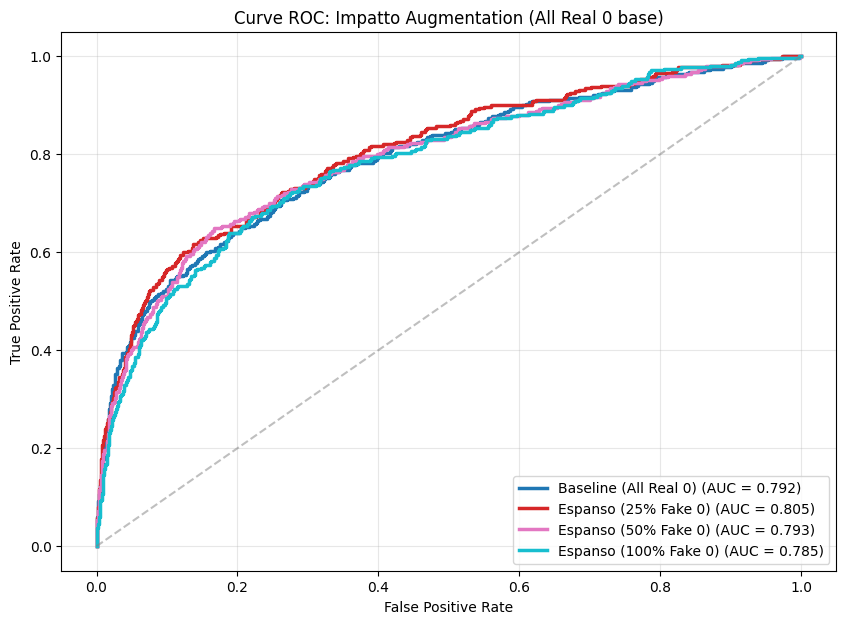

In [8]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.utils.data import ConcatDataset, Subset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Riferimento fisso per FID: Classe 1 del Test Set Reale
from torch.utils.data import Subset, ConcatDataset, DataLoader
import torch

# Parametri fissi dai tuoi dati reali
n_real_0 = len(real_0_ds) # es. 1400
n_real_1 = len(real_1_ds) # es. 200

# Nuova lista scenari corretta
scenarios = [
    {"name": "Baseline (All Real 0)",    "ratio": 0.0}, # Solo Real 0 + Fake 1 per pareggiare
    {"name": "Espanso (25% Fake 0)",    "ratio": 0.25},
    {"name": "Espanso (50% Fake 0)",    "ratio": 0.5},
    {"name": "Espanso (100% Fake 0)",   "ratio": 1.0}
]

def get_x(ds):
    if ds is None or len(ds) == 0: return None
    x = torch.stack([img for img, _ in ds])
    return x.unsqueeze(1) if x.ndim == 3 else x

final_results = {}

for sc in scenarios:
    name = sc["name"]
    ratio = sc["ratio"]
    
    print(f"\n>>> Scenario: {name} | Ratio: {ratio}")

    # --- COSTRUZIONE DATASET ---
    n_fake_0 = int(n_real_0 * ratio)
    s_fake_0 = Subset(fake_0_ds, torch.randperm(len(fake_0_ds))[:n_fake_0]) if n_fake_0 > 0 else None
    ds_0_mixed = ConcatDataset([real_0_ds, s_fake_0]) if s_fake_0 else real_0_ds
    
    total_target = len(ds_0_mixed)
    n_fake_1 = total_target - n_real_1
    s_fake_1 = Subset(fake_1_ds, torch.randperm(len(fake_1_ds))[:n_fake_1])
    ds_1_mixed = ConcatDataset([real_1_ds, s_fake_1])

    # --- TRAINING ---
    model = EEGNetModel(chans=8, classes=2, time_points=128).to(device)
    trainer = TrainModel()
    trained_m = trainer.train_model(model, ds_0_mixed, ds_1_mixed, epochs=300, fake_ratio_in_c1=0.0)
    
    # --- VALUTAZIONE PERFORMANCE ---
    m = evaluate_advanced_metrics(trained_m, test_dataset, device)
    
    # --- ESTRAZIONE FEATURE PER FID ---
    # Prepariamo tutti i blocchi necessari
    x_tr0 = get_x(real_0_ds)
    x_tr1 = get_x(real_1_ds)
    x_te0 = get_x(test_0_piece)
    x_te1 = get_x(test_1_piece)
    x_sy0 = get_x(s_fake_0) # Può essere None
    x_sy1 = get_x(s_fake_1)

    # Estrazione feature (solo se il blocco esiste)
    f_tr0 = get_eegnet_features(trained_m, x_tr0, device)
    f_tr1 = get_eegnet_features(trained_m, x_tr1, device)
    f_te0 = get_eegnet_features(trained_m, x_te0, device)
    f_te1 = get_eegnet_features(trained_m, x_te1, device)
    f_sy0 = get_eegnet_features(trained_m, x_sy0, device) if x_sy0 is not None else None
    f_sy1 = get_eegnet_features(trained_m, x_sy1, device)

    # --- CALCOLO FID (TUTTE LE COMBINAZIONI) ---
    # 1. Real Train vs Real Test (Benchmark di discrepanza del dataset)
    m["fid_tr0_te0"] = calculate_frechet_distance(f_tr0, f_te0)
    m["fid_tr1_te1"] = calculate_frechet_distance(f_tr1, f_te1)
    
    # 2. Real Train vs Synthetic (Fedeltà della GAN rispetto all'addestramento)
    m["fid_tr0_sy0"] = calculate_frechet_distance(f_tr0, f_sy0) if f_sy0 is not None else None
    m["fid_tr1_sy1"] = calculate_frechet_distance(f_tr1, f_sy1)
    
    # 3. Synthetic vs Real Test (Utilità: i sintetici coprono il test set?)
    m["fid_sy0_te0"] = calculate_frechet_distance(f_sy0, f_te0) if f_sy0 is not None else None
    m["fid_sy1_te1"] = calculate_frechet_distance(f_sy1, f_te1)

    # Metadati proporzioni
    m.update({
        "n_real_0": n_real_0, "n_fake_0": n_fake_0,
        "n_real_1": n_real_1, "n_fake_1": n_fake_1,
        "total": len(ds_0_mixed) + len(ds_1_mixed)
    })
    
    final_results[name] = m
    

# ==============================================================================================================
# TABELLA RIASSUNTIVA FINALE
# ==============================================================================================================
# Definizione larghezza colonne
# Formattatore per i valori FID (gestisce None con "-")
def fmt(val): return f"{val:6.2f}" if val is not None else "   -  "

print("\n" + "="*120)
print(f"{'ANALISI COMPLETA: PERFORMANCE, COMPOSIZIONE E DISTANZE FRECHET (FID)':^120}")
print("="*120)
header = (f"{'SCENARIO':<25} | {'B-ACC':<6} | {'REAL':<9} | {'FAKE':<9} | "
          f"{'TR vs TE (C1)':<12} | {'TR vs SY (C1)':<12} | {'SY vs TE (C1)':<12}")
print(header)
print("-" * 120)

for name, res in final_results.items():
    real_c = f"{res['n_real_0']}/{res['n_real_1']}"
    fake_c = f"{res['n_fake_0']}/{res['n_fake_1']}"
    
    # Ci concentriamo sulla Classe 1 (Target) che è quella critica per il bilanciamento
    f_tr_te = fmt(res['fid_tr1_te1'])
    f_tr_sy = fmt(res['fid_tr1_sy1'])
    f_sy_te = fmt(res['fid_sy1_te1'])
    
    print(f"{name:<25} | {res['b_acc']:.4f} | {real_c:<9} | {fake_c:<9} | "
          f"{f_tr_te:<12} | {f_tr_sy:<12} | {f_sy_te:<12}")

print("="*120)
print("Legenda FID (Classe 1):")
print(" - TR vs TE: Quanto il Test Reale è diverso dal Train Reale (Dataset Shift)")
print(" - TR vs SY: Quanto i Sintetici sono simili ai dati con cui la GAN è stata addestrata (Fedeltà)")
print(" - SY vs TE: Quanto i Sintetici 'coprono' la distribuzione del Test Set (Potenziale di Generalizzazione)")
# ==============================================================================================================
# PLOT DELLE CURVE ROC
# ==============================================================================================================
import matplotlib.cm as cm

plt.figure(figsize=(10, 7))
n_sc = len(final_results)
# Genera colori dinamicamente per evitare IndexError
colors = cm.get_cmap('tab10')(np.linspace(0, 1, n_sc))

for i, (name, m) in enumerate(final_results.items()):
    plt.plot(m['fpr'], m['tpr'], color=colors[i], lw=2.5, 
             label=f"{name} (AUC = {m['auc']:.3f})")

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curve ROC: Impatto Augmentation (All Real 0 base)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()